# OpenVSP Stability-Focused Analysis and Optimization

This notebook replaces the old AoA-as-design-variable workflow with a stability-driven workflow.
The aerodynamic sweep still runs at the alpha schedule requested in `BASELINE_ANALYSIS`, but the design
variables now act on flight-mechanics-relevant quantities:

- `Vtail / XForm / X_Location`
- `Vtail / XForm / Z_Location`
- `VSPAEROSweep / Xcg`

The `.stab` file is treated as the authoritative source for the stability metrics used in the sweeps and optimization.
Every baseline and sweep case is exported to both `.csv` and `.txt` so the downstream optimization pipeline can reuse the results outside the notebook.

In [23]:
from __future__ import annotations

import importlib
import platform
import sys
from datetime import datetime
from pathlib import Path

import pandas as pd


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "vspopt").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the notebook working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from vspopt import (
    check_vsp3_integrity,
    configure_embedded_openvsp,
    detect_supported_python_versions,
    format_supported_python_versions,
    get_default_openvsp_root,
    setup_logging,
)

EXPORT_ROOT = REPO_ROOT / "exports"
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)
SESSION_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_ROOT = EXPORT_ROOT / f"notebook_{SESSION_STAMP}"
RUN_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_PATH = REPO_ROOT / "models" / "VESPA2.vsp3"

setup_logging(level="INFO", log_file=RUN_ROOT / "notebook.log")
OPENVSP_ROOT = configure_embedded_openvsp()
SUPPORTED_PYTHON = detect_supported_python_versions(OPENVSP_ROOT)
MODEL_OK, MODEL_MESSAGE = check_vsp3_integrity(MODEL_PATH)

package_rows = []
for package_name in ["numpy", "pandas", "scipy", "optuna", "plotly", "matplotlib"]:
    try:
        module = importlib.import_module(package_name)
        version = getattr(module, "__version__", "<unknown>")
        package_rows.append({"package": package_name, "status": "available", "version": version})
    except Exception as exc:
        package_rows.append({"package": package_name, "status": f"missing: {exc}", "version": ""})

import openvsp as vsp

env_rows = [
    {"check": "repo_root", "value": str(REPO_ROOT)},
    {"check": "run_root", "value": str(RUN_ROOT)},
    {"check": "model_path", "value": str(MODEL_PATH)},
    {"check": "model_integrity", "value": MODEL_MESSAGE},
    {"check": "python_executable", "value": sys.executable},
    {"check": "python_version", "value": platform.python_version()},
    {"check": "openvsp_root", "value": str(OPENVSP_ROOT)},
    {"check": "openvsp_default_root", "value": str(get_default_openvsp_root())},
    {"check": "openvsp_supported_python", "value": format_supported_python_versions(SUPPORTED_PYTHON)},
    {"check": "set_first_user", "value": getattr(vsp, "SET_FIRST_USER", "<missing>")},
    {"check": "stability_default", "value": getattr(vsp, "STABILITY_DEFAULT", "<missing>")},
]

display(pd.DataFrame(env_rows))
display(pd.DataFrame(package_rows))

if not MODEL_OK:
    raise RuntimeError(MODEL_MESSAGE)

print("Environment bootstrap completed successfully.")

,check,value
0,repo_root,C:\Users\gabri\Desktop\TEAM\OpenVspController
1,run_root,C:\Users\gabri\Desktop\TEAM\OpenVspController\...
2,model_path,C:\Users\gabri\Desktop\TEAM\OpenVspController\...
3,model_integrity,OK (size=1189.4 KB)
4,python_executable,c:\Users\gabri\Desktop\TEAM\OpenVspController\...
5,python_version,3.13.13
6,openvsp_root,C:\Users\gabri\Desktop\TEAM\OpenVspController\...
7,openvsp_default_root,C:\Users\gabri\Desktop\TEAM\OpenVspController\...
8,openvsp_supported_python,Python 3.13
9,set_first_user,3


,package,status,version
0,numpy,available,2.4.4
1,pandas,available,3.0.2
2,scipy,missing: No module named 'scipy',
3,optuna,missing: No module named 'optuna',
4,plotly,missing: No module named 'plotly',
5,matplotlib,available,3.10.8


Environment bootstrap completed successfully.


## Baseline configuration

The notebook keeps a baseline analysis block and separates the one-at-a-time design-variable sweeps.
The default alpha schedule is intentionally set to a single reference alpha because stability-enabled VSPAERO
cases are expensive. Once the `.stab` pipeline is validated, increase `alpha_start`, `alpha_end`, and
`alpha_npts` if you want a larger aerodynamic schedule.

In [24]:
import numpy as np

BASELINE_ANALYSIS = {
    "alpha_start": 0.0,
    "alpha_end": 0.0,
    "alpha_npts": 1,
    "mach": 0.12,
    "re_cref": 8.5e5,
    "wake_iter": 1,
    "parse_history": True,
    "parse_stability": True,
    "require_stability_file": True,
    "redirect_solver_output": True,
}

BASELINE_CONTROL_DEFLECTIONS = {
    "Ailerons": 0.0,
    "Ruddervators": 0.0,
}

# Symmetric sweep deltas around the baseline values.
# Keep these short at first because each stability-enabled case can take minutes.
SWEEP_DELTAS = {
    "Tail X location": np.array([-0.05, 0.05]),
    "Tail Z location": np.array([-0.03, 0.03]),
    "CG X": np.array([-0.03, 0.03]),
}

# Optimization bounds are defined as deltas around the loaded baseline state.
OPTIMIZATION_BOUNDS = {
    "Tail X location": (-0.08, 0.08),
    "Tail Z location": (-0.04, 0.04),
    "CG X": (-0.04, 0.04),
}

OPTIMIZATION_SETTINGS = {
    "gradient_options": {"maxiter": 8, "ftol": 1e-3, "disp": True},
    "bayesian_trials": 4,
    "two_phase_bayesian_trials": 4,
    "seed": 42,
}

print("Baseline analysis settings:")
for key, value in BASELINE_ANALYSIS.items():
    print(f"  {key}: {value}")

Baseline analysis settings:
  alpha_start: 0.0
  alpha_end: 0.0
  alpha_npts: 1
  mach: 0.12
  re_cref: 850000.0
  wake_iter: 1
  parse_history: True
  parse_stability: True
  require_stability_file: True
  redirect_solver_output: True


## Model loading and variable selection

This section loads the model, assigns thin/thick aero sets, records the baseline geometry state,
and validates the exact OpenVSP names used later by the sweep and optimization code.

In [25]:
from IPython.display import display

from vspopt import AircraftModel, DesignVariable, validate_design_variables

TAIL_X_KEY = ("Vtail", "X_Location", "XForm")
TAIL_Z_KEY = ("Vtail", "Z_Location", "XForm")

model = AircraftModel(MODEL_PATH).load()
wrapper = model.wrapper

AERO_SET_ASSIGNMENT = wrapper.setup_dual_aero_sets(
    thin_keywords=["Wing", "tail", "Fin", "Stabilizer", "vtail"],
    thick_keywords=["Fuselage", "Body", "hull", "Fuse"],
)

BASELINE_GEOMETRY = {
    TAIL_X_KEY: float(wrapper.get_param(*TAIL_X_KEY)),
    TAIL_Z_KEY: float(wrapper.get_param(*TAIL_Z_KEY)),
}
BASELINE_CG = dict(wrapper.get_vspaero_reference_cg())
CONTROL_GROUPS = wrapper.get_control_surface_groups()
AVAILABLE_SWEEP_INPUTS = sorted(wrapper.get_available_analysis_inputs("VSPAEROSweep"))

DESIGN_VARIABLES = [
    DesignVariable.geometry(
        label="Tail X location",
        geom_name=TAIL_X_KEY[0],
        parm_name=TAIL_X_KEY[1],
        group_name=TAIL_X_KEY[2],
        lower=BASELINE_GEOMETRY[TAIL_X_KEY] + OPTIMIZATION_BOUNDS["Tail X location"][0],
        upper=BASELINE_GEOMETRY[TAIL_X_KEY] + OPTIMIZATION_BOUNDS["Tail X location"][1],
        initial=BASELINE_GEOMETRY[TAIL_X_KEY],
        units="m",
        description="Longitudinal tail position relative to the fuselage reference frame.",
    ),
    DesignVariable.geometry(
        label="Tail Z location",
        geom_name=TAIL_Z_KEY[0],
        parm_name=TAIL_Z_KEY[1],
        group_name=TAIL_Z_KEY[2],
        lower=BASELINE_GEOMETRY[TAIL_Z_KEY] + OPTIMIZATION_BOUNDS["Tail Z location"][0],
        upper=BASELINE_GEOMETRY[TAIL_Z_KEY] + OPTIMIZATION_BOUNDS["Tail Z location"][1],
        initial=BASELINE_GEOMETRY[TAIL_Z_KEY],
        units="m",
        description="Vertical tail position relative to the baseline vehicle centerline.",
    ),
    DesignVariable.analysis_input_variable(
        label="CG X",
        analysis_input="Xcg",
        lower=BASELINE_CG["Xcg"] + OPTIMIZATION_BOUNDS["CG X"][0],
        upper=BASELINE_CG["Xcg"] + OPTIMIZATION_BOUNDS["CG X"][1],
        initial=BASELINE_CG["Xcg"],
        units="m",
        description="Reference center of gravity used by the VSPAERO stability analysis.",
    ),
]

selected_targets = pd.DataFrame(
    [
        {
            "label": "Tail X location",
            "target": "Vtail / XForm / X_Location",
            "baseline_value": BASELINE_GEOMETRY[TAIL_X_KEY],
        },
        {
            "label": "Tail Z location",
            "target": "Vtail / XForm / Z_Location",
            "baseline_value": BASELINE_GEOMETRY[TAIL_Z_KEY],
        },
        {
            "label": "CG X",
            "target": "VSPAEROSweep / Xcg",
            "baseline_value": BASELINE_CG["Xcg"],
        },
    ]
)

print("Thin components:", AERO_SET_ASSIGNMENT["thin_components"])
print("Thick components:", AERO_SET_ASSIGNMENT["thick_components"])
print("Control-surface groups:", [group["name"] for group in CONTROL_GROUPS])
print("Selected VSPAERO inputs:", [name for name in AVAILABLE_SWEEP_INPUTS if name in {"Xcg", "Ycg", "Zcg", "GeomSet", "ThinGeomSet", "UnsteadyType", "RedirectFile"}])

display(model.geometry_table().round(4))
display(selected_targets)
display(validate_design_variables(wrapper, DESIGN_VARIABLES))

ImportError: cannot import name 'validate_design_variables' from 'vspopt' (C:\Users\gabri\Desktop\TEAM\OpenVspController\vspopt\__init__.py)

In [26]:
from vspopt import export_case_collection, print_case_collection_summary


def restore_baseline_state() -> None:
    """Reset geometry, CG, and control-surface deflections before each case."""
    wrapper.set_params(BASELINE_GEOMETRY)
    wrapper.set_vspaero_reference_cg(
        xcg=BASELINE_CG["Xcg"],
        ycg=BASELINE_CG["Ycg"],
        zcg=BASELINE_CG["Zcg"],
    )
    wrapper.set_control_surface_deflections(BASELINE_CONTROL_DEFLECTIONS)
    wrapper._vsp.Update()



def current_state_snapshot() -> dict[str, float]:
    """Read the variables we care about after the latest baseline/sweep/optimization update."""
    cg = wrapper.get_vspaero_reference_cg()
    return {
        "tail_x": float(wrapper.get_param(*TAIL_X_KEY)),
        "tail_z": float(wrapper.get_param(*TAIL_Z_KEY)),
        "xcg": float(cg["Xcg"]),
        "ycg": float(cg["Ycg"]),
        "zcg": float(cg["Zcg"]),
    }



def build_case_metadata(case_name: str, sweep_variable: str = "baseline", swept_value: float | None = None) -> dict[str, float | str]:
    """Store the design-variable state that generated a particular result."""
    snapshot = current_state_snapshot()
    return {
        "case_name": case_name,
        "sweep_variable": sweep_variable,
        "swept_value": float("nan") if swept_value is None else float(swept_value),
        "tail_x": snapshot["tail_x"],
        "tail_z": snapshot["tail_z"],
        "xcg": snapshot["xcg"],
        "tail_x_from_cg": snapshot["tail_x"] - snapshot["xcg"],
        "tail_z_from_cg": snapshot["tail_z"] - snapshot["zcg"],
    }



def run_named_case(
    case_name: str,
    *,
    geometry_updates: dict[tuple[str, str, str], float] | None = None,
    sweep_overrides: dict[str, float] | None = None,
    case_group: str = "cases",
    sweep_variable: str = "baseline",
    swept_value: float | None = None,
):
    """
    Run one isolated case.

    The helper always resets the baseline first, then applies exactly one set of
    overrides. This keeps the notebook honest: each sweep point is compared
    against the same starting configuration instead of accumulating changes.
    """
    restore_baseline_state()

    if geometry_updates:
        wrapper.set_params(geometry_updates)

    run_kwargs = dict(BASELINE_ANALYSIS)
    run_kwargs["control_surface_deflections"] = dict(BASELINE_CONTROL_DEFLECTIONS)
    if sweep_overrides:
        run_kwargs.update(sweep_overrides)

    case_dir = RUN_ROOT / case_group
    case_dir.mkdir(parents=True, exist_ok=True)

    result = wrapper.run_vspaero_sweep(
        working_dir=case_dir,
        output_stem=case_name,
        **run_kwargs,
    )
    metadata = build_case_metadata(case_name, sweep_variable=sweep_variable, swept_value=swept_value)
    return result, metadata


restore_baseline_state()
print("Baseline state restored and helper functions are ready.")

ImportError: cannot import name 'export_case_collection' from 'vspopt' (C:\Users\gabri\Desktop\TEAM\OpenVspController\vspopt\__init__.py)

## Baseline stability case

The baseline case runs with `require_stability_file=True`, so the notebook stops immediately if the `.stab`
file is missing or unusable. The exported tables are written to both CSV and TXT.

In [27]:
baseline_results = {}
baseline_metadata = {}

baseline, baseline_meta = run_named_case(
    "baseline_reference",
    case_group="baseline",
    sweep_variable="baseline",
)

baseline_results["baseline_reference"] = baseline
baseline_metadata["baseline_reference"] = baseline_meta

baseline_summary = print_case_collection_summary(baseline_results, baseline_metadata)
baseline_exports = export_case_collection(
    baseline_results,
    RUN_ROOT / "tables",
    "baseline",
    case_metadata=baseline_metadata,
)

print("Baseline export files:")
for key, path in baseline_exports.items():
    print(f"  {key}: {path}")

display(baseline.to_dataframe().round(6))
display(baseline.stability_dataframe().round(6))

NameError: name 'run_named_case' is not defined

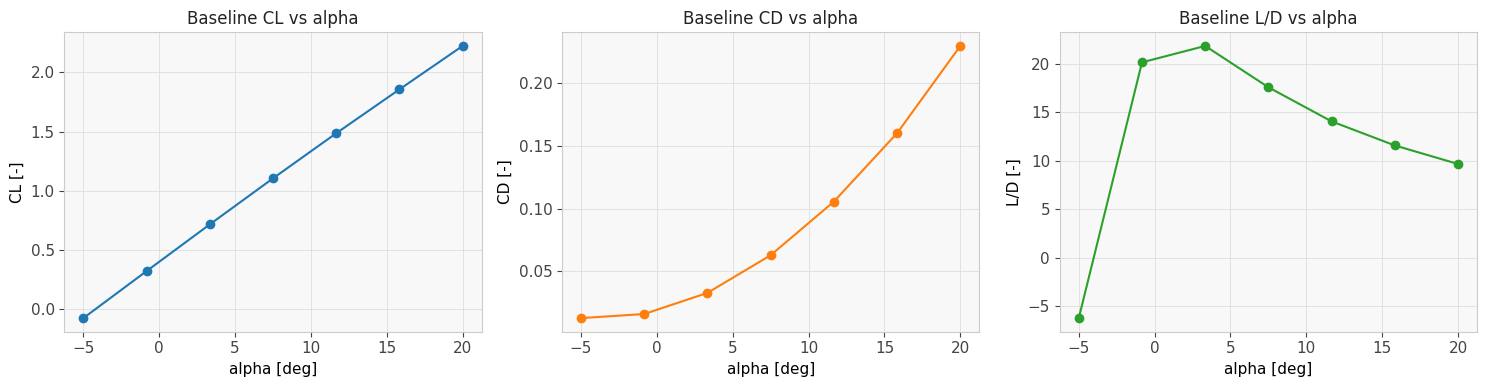

In [28]:
import matplotlib.pyplot as plt

baseline_aero_df = baseline.to_dataframe().copy()
baseline_stab_df = baseline.stability_dataframe().copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if not baseline_aero_df.empty:
    axes[0].plot(baseline_aero_df["alpha [deg]"], baseline_aero_df["CL [-]"], marker="o")
    axes[0].set_title("Baseline CL vs alpha")
    axes[0].set_xlabel("alpha [deg]")
    axes[0].set_ylabel("CL [-]")
    axes[0].grid(True)

    axes[1].plot(baseline_aero_df["alpha [deg]"], baseline_aero_df["CD [-]"], marker="o", color="tab:orange")
    axes[1].set_title("Baseline CD vs alpha")
    axes[1].set_xlabel("alpha [deg]")
    axes[1].set_ylabel("CD [-]")
    axes[1].grid(True)

    axes[2].plot(baseline_aero_df["alpha [deg]"], baseline_aero_df["L/D [-]"], marker="o", color="tab:green")
    axes[2].set_title("Baseline L/D vs alpha")
    axes[2].set_xlabel("alpha [deg]")
    axes[2].set_ylabel("L/D [-]")
    axes[2].grid(True)

plt.tight_layout()
plt.show()

if not baseline_stab_df.empty:
    display(
        baseline_stab_df[
            [column for column in ["AoA", "CL", "CD", "CMy", "SM", "X_np"] if column in baseline_stab_df.columns]
        ].round(6)
    )

## One-at-a-time stability sweeps

The sweep section changes one variable at a time around the baseline state and exports the combined results.
The derived columns `tail_x_from_cg` and `tail_z_from_cg` make it easier to see how the tail location relative
to the center of gravity drives the `.stab` outputs.

In [29]:
BASELINE_SWEEP_VALUES = {
    "Tail X location": BASELINE_GEOMETRY[TAIL_X_KEY],
    "Tail Z location": BASELINE_GEOMETRY[TAIL_Z_KEY],
    "CG X": BASELINE_CG["Xcg"],
}

SWEEP_CASE_DEFINITIONS = {
    "Tail X location": BASELINE_SWEEP_VALUES["Tail X location"] + SWEEP_DELTAS["Tail X location"],
    "Tail Z location": BASELINE_SWEEP_VALUES["Tail Z location"] + SWEEP_DELTAS["Tail Z location"],
    "CG X": BASELINE_SWEEP_VALUES["CG X"] + SWEEP_DELTAS["CG X"],
}

display(
    pd.DataFrame(
        [
            {"variable": label, "values": ", ".join(f"{value:.4f}" for value in values)}
            for label, values in SWEEP_CASE_DEFINITIONS.items()
        ]
    )
)

sweep_results = {}
sweep_metadata = {}

for sweep_variable, values in SWEEP_CASE_DEFINITIONS.items():
    for index, value in enumerate(values, start=1):
        case_name = f"{sweep_variable.lower().replace(' ', '_')}_{index}"
        geometry_updates = None
        sweep_overrides = None

        if sweep_variable == "Tail X location":
            geometry_updates = {TAIL_X_KEY: float(value)}
        elif sweep_variable == "Tail Z location":
            geometry_updates = {TAIL_Z_KEY: float(value)}
        elif sweep_variable == "CG X":
            sweep_overrides = {"xcg": float(value)}
        else:
            raise ValueError(f"Unsupported sweep variable: {sweep_variable}")

        result, metadata = run_named_case(
            case_name,
            geometry_updates=geometry_updates,
            sweep_overrides=sweep_overrides,
            case_group="sweeps",
            sweep_variable=sweep_variable,
            swept_value=float(value),
        )
        sweep_results[case_name] = result
        sweep_metadata[case_name] = metadata

sweep_summary = print_case_collection_summary(sweep_results, sweep_metadata)
sweep_exports = export_case_collection(
    sweep_results,
    RUN_ROOT / "tables",
    "sweep",
    case_metadata=sweep_metadata,
)

print("Sweep export files:")
for key, path in sweep_exports.items():
    print(f"  {key}: {path}")

NameError: name 'BASELINE_GEOMETRY' is not defined

In [30]:
sweep_display_df = sweep_summary[
    [
        column
        for column in [
            "case_name",
            "sweep_variable",
            "swept_value",
            "tail_x",
            "tail_z",
            "xcg",
            "tail_x_from_cg",
            "tail_z_from_cg",
            "ld_max",
            "static_margin",
            "neutral_point_x",
            "has_stab",
        ]
        if column in sweep_summary.columns
    ]
].copy()

display(sweep_display_df.round(6))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
baseline_static_margin = float(baseline.static_margin)
baseline_neutral_point = float(baseline.neutral_point_x)
baseline_tail_arm = float(baseline_meta["tail_x_from_cg"])

for sweep_variable, group in sweep_display_df.groupby("sweep_variable"):
    ordered = group.sort_values("swept_value")
    axes[0].plot(ordered["swept_value"], ordered["static_margin"], marker="o", label=sweep_variable)
    axes[1].plot(ordered["swept_value"], ordered["neutral_point_x"], marker="o", label=sweep_variable)
    axes[2].plot(ordered["tail_x_from_cg"], ordered["static_margin"], marker="o", label=sweep_variable)

axes[0].axhline(baseline_static_margin, color="black", linestyle="--", linewidth=1.0)
axes[0].set_title("Static margin vs swept value")
axes[0].set_xlabel("Swept value [m]")
axes[0].set_ylabel("Static margin [-]")
axes[0].grid(True)
axes[0].legend()

axes[1].axhline(baseline_neutral_point, color="black", linestyle="--", linewidth=1.0)
axes[1].set_title("Neutral point vs swept value")
axes[1].set_xlabel("Swept value [m]")
axes[1].set_ylabel("X_np [m]")
axes[1].grid(True)
axes[1].legend()

axes[2].axvline(baseline_tail_arm, color="black", linestyle="--", linewidth=1.0)
axes[2].set_title("Static margin vs tail arm to CG")
axes[2].set_xlabel("tail_x - xcg [m]")
axes[2].set_ylabel("Static margin [-]")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

NameError: name 'sweep_summary' is not defined

## Optimization setup

The optimization section reuses the same validated variables as the sweep section.
`Xcg` is validated with the exact OpenVSP name, but the optimizer applies it back to `run_vspaero_sweep`
through the corrected Python keyword mapping, so the first half of the notebook and the optimization module now
use the same variable names consistently.

In [31]:
from vspopt import ObjectiveSpec, compare_results, run_bayesian_optimization, run_gradient_optimization, run_two_phase_optimization

reference_ld = float(baseline.LD_max) if np.isfinite(baseline.LD_max) else float("nan")
objective_constraints = []
if np.isfinite(reference_ld):
    objective_constraints.append(("LD_max", ">=", reference_ld * 0.95))

objective = ObjectiveSpec(
    metrics=[("static_margin", -1.0), ("LD_max", -0.05)],
    constraints=objective_constraints,
)

optimization_sweep_kwargs = dict(BASELINE_ANALYSIS)
optimization_sweep_kwargs.update(
    {
        "working_dir": RUN_ROOT / "optimization_evals",
        "output_stem": "opt_eval",
        "control_surface_deflections": dict(BASELINE_CONTROL_DEFLECTIONS),
    }
)

print("Objective metrics:", objective.metrics)
print("Objective constraints:", objective.constraints)
display(validate_design_variables(wrapper, DESIGN_VARIABLES))

Objective metrics: [('static_margin', -1.0), ('LD_max', -0.05)]
Objective constraints: [('LD_max', '>=', 20.7553345850252)]


NameError: name 'validate_design_variables' is not defined

In [32]:
restore_baseline_state()
gradient_result = run_gradient_optimization(
    wrapper,
    DESIGN_VARIABLES,
    objective,
    sweep_kwargs=optimization_sweep_kwargs,
    options=OPTIMIZATION_SETTINGS["gradient_options"],
)

display(pd.DataFrame([gradient_result.summary_series()]).round(6))

NameError: name 'restore_baseline_state' is not defined

In [33]:
restore_baseline_state()
bayesian_result = run_bayesian_optimization(
    wrapper,
    DESIGN_VARIABLES,
    objective,
    sweep_kwargs=optimization_sweep_kwargs,
    n_trials=OPTIMIZATION_SETTINGS["bayesian_trials"],
    seed=OPTIMIZATION_SETTINGS["seed"],
    show_progress=False,
)

display(pd.DataFrame([bayesian_result.summary_series()]).round(6))

NameError: name 'restore_baseline_state' is not defined

In [34]:
restore_baseline_state()
two_phase_bayesian, two_phase_slsqp = run_two_phase_optimization(
    wrapper,
    DESIGN_VARIABLES,
    objective,
    sweep_kwargs=optimization_sweep_kwargs,
    n_bayesian_trials=OPTIMIZATION_SETTINGS["two_phase_bayesian_trials"],
    slsqp_options=OPTIMIZATION_SETTINGS["gradient_options"],
    seed=OPTIMIZATION_SETTINGS["seed"],
)

optimizer_comparison = compare_results([gradient_result, bayesian_result, two_phase_slsqp])
display(optimizer_comparison.round(6))

fig, ax = plt.subplots(figsize=(9, 4))
for result in [gradient_result, bayesian_result, two_phase_slsqp]:
    ax.plot(result.history_obj, marker="o", label=result.method)
ax.set_title("Optimization objective history")
ax.set_xlabel("Evaluation")
ax.set_ylabel("Objective value")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'restore_baseline_state' is not defined

In [35]:
restore_baseline_state()
optimized_sweep_kwargs = two_phase_slsqp.apply_best(
    wrapper,
    sweep_kwargs={
        **BASELINE_ANALYSIS,
        "control_surface_deflections": dict(BASELINE_CONTROL_DEFLECTIONS),
    },
)
optimized = wrapper.run_vspaero_sweep(
    working_dir=RUN_ROOT / "optimized",
    output_stem="optimized_two_phase",
    **optimized_sweep_kwargs,
)
optimized_metadata = build_case_metadata("optimized_two_phase", sweep_variable="optimizer")

comparison_cases = {
    "baseline_reference": baseline,
    "optimized_two_phase": optimized,
}
comparison_metadata = {
    "baseline_reference": baseline_meta,
    "optimized_two_phase": optimized_metadata,
}
comparison_exports = export_case_collection(
    comparison_cases,
    RUN_ROOT / "tables",
    "baseline_vs_optimized",
    case_metadata=comparison_metadata,
)

print("Baseline vs optimized export files:")
for key, path in comparison_exports.items():
    print(f"  {key}: {path}")

performance_comparison = pd.DataFrame(
    {
        "baseline_reference": baseline.performance_summary(),
        "optimized_two_phase": optimized.performance_summary(),
    }
)
display(performance_comparison.round(6))

display(optimized.stability_dataframe().round(6))

NameError: name 'restore_baseline_state' is not defined